### DATOS DEL SENSOR EN EL MOTOR DE 2025

Queremos analizar los datos recogidos con nuestro sensor del combustible del motor. Los datos que tenemos son el voltaje y el tiempo. Para ello haremos primero un eda y después pasaremos a procesar la señal y sacar las gráficas que nos interesan.

In [1]:
#Primero importamos las librerias
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
from scipy import signal
import pywt

%matplotlib inline

#Leemos los datos
df = pd.read_csv("sensores/Measurement_17_15.asc", sep=r"\s+", skiprows=2)
df

,Begin,Triggerblock,Fri,May,15,07:26:14,pm,2026
0,0.170000,SV:,1,0,0.0,::sysAnalog_01,=,0.000
1,0.170000,SV:,1,0,0.0,::sysAnalog_02,=,0.000
2,0.170000,SV:,1,0,0.0,::sysAnalog_03,=,0.000
3,0.172000,SV:,1,0,0.0,::sysAnalog_03,=,0.659
4,0.174000,SV:,1,0,0.0,::sysAnalog_03,=,0.641
...,...,...,...,...,...,...,...,...
42578,60.994000,SV:,1,0,0.0,::sysAnalog_03,=,0.712
42579,60.996000,SV:,1,0,0.0,::sysAnalog_03,=,0.605
42580,60.998000,SV:,1,0,0.0,::sysAnalog_03,=,0.356
42581,60.999000,log,trigger,event,NaN,NaN,NaN,NaN


Vemos que los datos, al no tener encabezado per se, nos interesan sólo las columnas Begin y 2026 que serían el tiempo y el voltaje así que vamos a eliminar el resto de columnas y renombrarlas.

In [2]:
#Primero borramos el resto de columnas
df_motor=df.drop(columns=["Triggerblock", "Fri", "May", "15", "pm"])
df_motor

,Begin,07:26:14,2026
0,0.170000,::sysAnalog_01,0.000
1,0.170000,::sysAnalog_02,0.000
2,0.170000,::sysAnalog_03,0.000
3,0.172000,::sysAnalog_03,0.659
4,0.174000,::sysAnalog_03,0.641
...,...,...,...
42578,60.994000,::sysAnalog_03,0.712
42579,60.996000,::sysAnalog_03,0.605
42580,60.998000,::sysAnalog_03,0.356
42581,60.999000,NaN,NaN


In [3]:
#Renombramos las columnas
df_motor=df_motor.rename(columns={
    'Begin':'tiempo',
    '07:26:14':'sensor',
    '2026':'voltaje'
})
df_motor

,tiempo,sensor,voltaje
0,0.170000,::sysAnalog_01,0.000
1,0.170000,::sysAnalog_02,0.000
2,0.170000,::sysAnalog_03,0.000
3,0.172000,::sysAnalog_03,0.659
4,0.174000,::sysAnalog_03,0.641
...,...,...,...
42578,60.994000,::sysAnalog_03,0.712
42579,60.996000,::sysAnalog_03,0.605
42580,60.998000,::sysAnalog_03,0.356
42581,60.999000,NaN,NaN


In [4]:
#Dividimos los sets, uno para cada sensor
df_sensor1=df_motor[df_motor['sensor']=='::sysAnalog_01'] #Temperatura (100Hz)
df_sensor2=df_motor[df_motor['sensor']=='::sysAnalog_02'] #Marchas(100Hz)
df_sensor3=df_motor[df_motor['sensor']=='::sysAnalog_03'] #Revoluciones (500Hz)

## Visualizar los set
Ahora que tenemos los set separados, podemos analizar los datos de cada uno. Primero los graficamos para ver que, obviamente, tenemos que tranformarlos

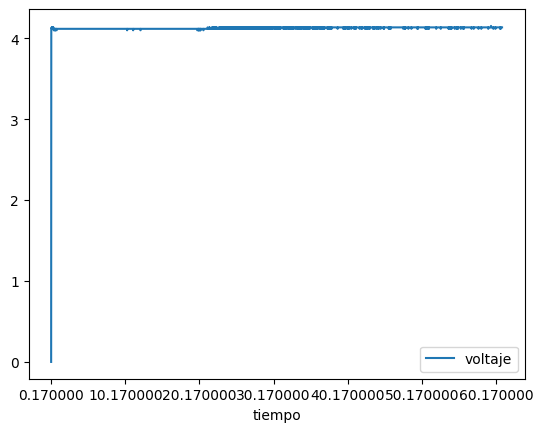

In [5]:
#Graficamos los datos del sensor 1
df_sensor1.plot(kind='line', x='tiempo', y='voltaje')
plt.show()

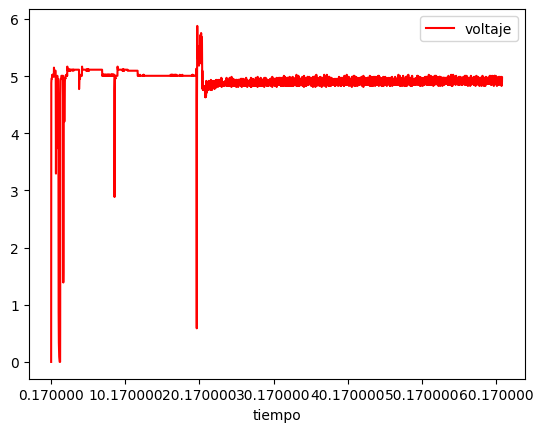

In [6]:
#Graficamos los datos del sensor 2
df_sensor2.plot(kind='line', x='tiempo', y='voltaje', style='red')
plt.show()

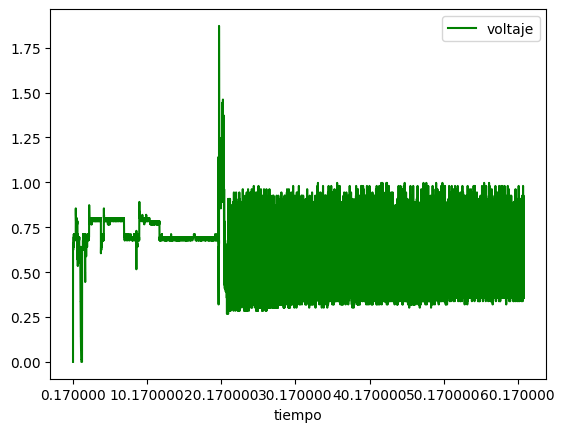

In [7]:
#Graficamos los datos del sensor 3
df_sensor3.plot(kind='line', x='tiempo', y='voltaje', style='green')
plt.show()

# Transformación de los datos - Sensor 1
Vamos a hacer la transformada de Fourier de los datos para poder tratarlos, en vez de en segundos(tiempo) en el régimen de frecuencias. Vamos a hacer un detrend en el voltaje por lo que pasamos las x e y a tipo numpy.

Podemos utilizar las funciones del módulo np.fft:

1-‘np.fft.fft()‘: Calcula la Transformada de Fourier discreta de una secuencia unidimensional.

2-‘np.fft.ifft()’: Calcula las Transformada Inversa de Fourier discreta de una secuencia unidimensional.

3-‘np.fft.fft2()’: Calcula la Transformada de Fourier bidimensional de una matriz.

4-‘np.fft.ifft2()’: Calcula la Transformada Inversa de Fourier bidimensional de una matriz.

5-‘np.fft.fftfreq()’: Genera las frecuencias correspondientes a las salidas de ‘fft‘.

6-‘np.fft.shift()’: Cambia el dominio de frecuencia de salida para centrarlo alrededor de cero.

7-‘np.fft.ishift()’: Deshacer el cambio generados por la función ‘shift()‘.

8-‘np.fft.rfft()’: Calcula la Transformada de Fourier discreta de valores reales.

9-‘np.fft.irfft()’: Calcula la Transformada Inversa de Fourier discreta para valores reales.

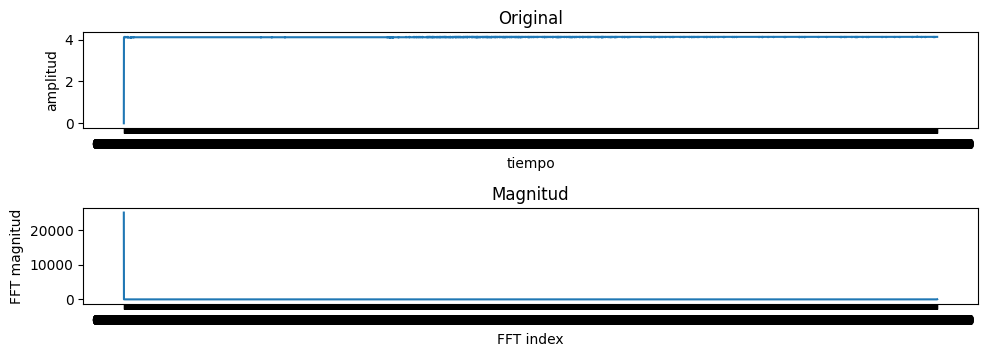

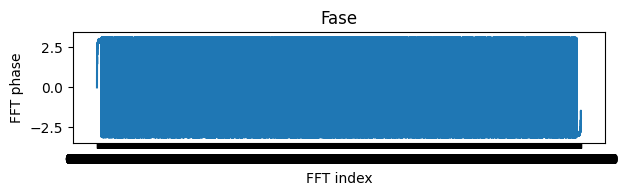

In [8]:
x1=np.array(df_sensor1.tiempo)
y1=np.array(df_sensor1.voltaje)

#Hacemos la transformada de Fourier
four_transf1=np.fft.fft(y1)
y1_mag=np.abs(four_transf1)
y1_phase=np.angle(four_transf1)

#Graficamos
plt.figure(figsize=(10,5))
#original
plt.subplot(3,1,1)
plt.plot(x1,y1)
plt.title('Original')
plt.xlabel('tiempo')
plt.ylabel('amplitud')
#Magnitud
plt.subplot(3,1,2)
plt.plot(x1,y1_mag)
plt.title('Magnitud')
plt.xlabel('FFT index')
plt.ylabel('FFT magnitud')
plt.tight_layout()
plt.show()
#Fase
plt.subplot(3,1,3)
plt.plot(x1,y1_phase)
plt.title('Fase')
plt.xlabel('FFT index')
plt.ylabel('FFT phase')
plt.tight_layout()
plt.show()


# Transformación de los datos - Sensor 2

In [9]:
df_sensor2

,tiempo,sensor,voltaje
1,0.170000,::sysAnalog_02,0.000
8,0.180000,::sysAnalog_02,4.775
15,0.190000,::sysAnalog_02,4.882
22,0.200000,::sysAnalog_02,4.918
29,0.210000,::sysAnalog_02,4.936
...,...,...,...
42547,60.950000,::sysAnalog_02,4.954
42554,60.960000,::sysAnalog_02,4.865
42561,60.970000,::sysAnalog_02,4.954
42568,60.980000,::sysAnalog_02,4.900


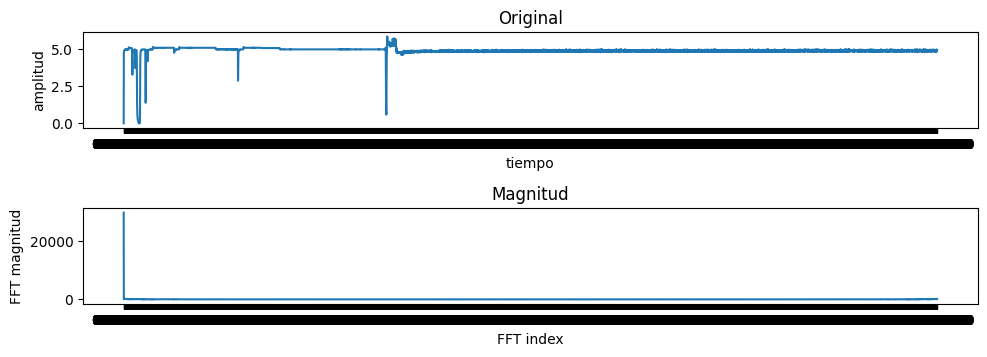

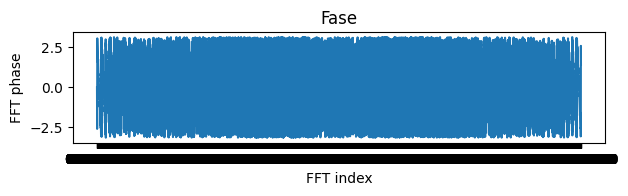

In [10]:
x2=np.array(df_sensor2.tiempo)
y2=np.array(df_sensor2.voltaje)

#Hacemos la transformada de Fourier
four_transf2=np.fft.fft(y2)
y2_mag=np.abs(four_transf2)
y2_phase=np.angle(four_transf2)

#Graficamos
plt.figure(figsize=(10,5))
#original
plt.subplot(3,1,1)
plt.plot(x2,y2)
plt.title('Original')
plt.xlabel('tiempo')
plt.ylabel('amplitud')
#Magnitud
plt.subplot(3,1,2)
plt.plot(x2,y2_mag)
plt.title('Magnitud')
plt.xlabel('FFT index')
plt.ylabel('FFT magnitud')
plt.tight_layout()
plt.show()
#Fase
plt.subplot(3,1,3)
plt.plot(x2,y2_phase)
plt.title('Fase')
plt.xlabel('FFT index')
plt.ylabel('FFT phase')
plt.tight_layout()
plt.show()


# Transformación de los datos - Sensor 3

In [11]:
df_sensor3

,tiempo,sensor,voltaje
2,0.170000,::sysAnalog_03,0.000
3,0.172000,::sysAnalog_03,0.659
4,0.174000,::sysAnalog_03,0.641
5,0.176000,::sysAnalog_03,0.641
6,0.178000,::sysAnalog_03,0.641
...,...,...,...
42576,60.990000,::sysAnalog_03,0.748
42577,60.992000,::sysAnalog_03,0.409
42578,60.994000,::sysAnalog_03,0.712
42579,60.996000,::sysAnalog_03,0.605


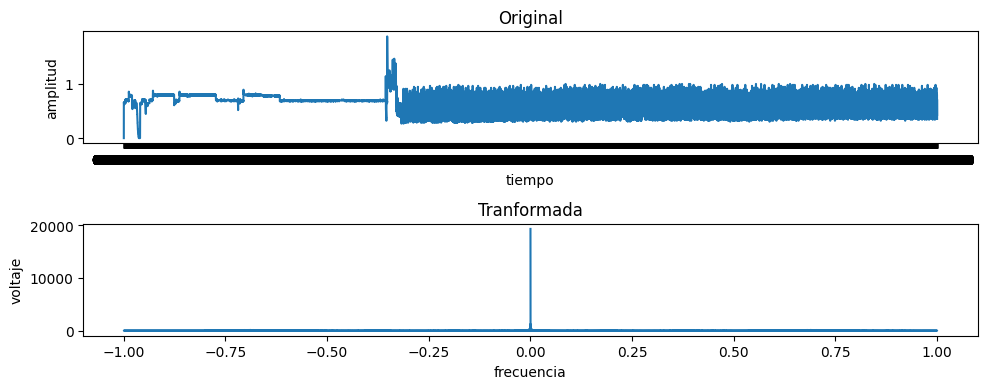

In [12]:

x3=np.array(df_sensor3.tiempo)
y3=np.array(df_sensor3.voltaje)

#Hacemos la transformada de Fourier
four_transf3=np.fft.fft(y3)
frecuencias3=np.fft.fftfreq(len(y3),0.5)

#Graficamos
plt.figure(figsize=(10,4))
#original
plt.subplot(2,1,1)
plt.plot(x3,y3)
plt.title('Original')
plt.xlabel('tiempo')
plt.ylabel('amplitud')
#transformada
plt.subplot(2,1,2)
plt.plot(frecuencias3,np.abs(four_transf3))
plt.title('Tranformada')
plt.xlabel('frecuencia')
plt.ylabel('voltaje')
plt.tight_layout()
plt.show()
